# Generating synthetic sequences with embedded regulatory grammars for RNA-binding proteins

In this notebook, we will generate synthetic sequences with implanted regulatory grammars, i.e. set of motifs.  Each regulatory grammar is defined by a set of motifs that are separated in space a specific distance.  In this simple dataset, only a single regulatory grammar is embedded within each sequence, which basically means that there is no useless motifs implanted, i.e. only sampling noise from the position weight matrices.  In addition, the start position of the regulatory grammar can be implanted in random locations on the seuqence, albeit the spacing between the motifs are conserved.  Details of the simulation procedure is outlined below.

In [2]:
import os, sys, h5py
import numpy as np
import pandas as pd
np.random.seed(22) # for reproducibility

## Process JASPAR pfm and convert to pwm

First we need to download the JASPAR motifs:

! wget http://jaspar.genereg.net/html/DOWNLOAD/JASPAR_CORE/pfm/nonredundant/pfm_vertebrates.txt -O ../data/synthetic_TF_dataset/pfm_vertebrates.txt

If this doesn't work, then you can download it manually from the link and place it in the ../data/synthetic_TF_dataset directory.


Next, we need to load and parse the JASPAR motifs and generate a pool of core motifs for CTCF, GABPA, SP1, SRF, and YY1, and a generic pool of motifs from which we will randomly sample from.  

In [3]:
def get_jaspar_motifs(file_path):
    def get_motif(f):
        line = f.readline()
        name = line.strip().split()[1]
        pfm = []
        for i in range(4):
            line = f.readline()
            if len(line.split()[1]) > 1:
                pfm.append(np.asarray(np.hstack([line.split()[1][1:], line.split()[2:-1]]), dtype=float))
            else:
                pfm.append(np.asarray(line.split()[2:-1], dtype=float))
        pfm = np.vstack(pfm)
        sum_pfm = np.sum(pfm, axis=0)
        pwm = pfm/np.outer(np.ones(4), sum_pfm)
        line = f.readline()
        return name, pwm

    num_lines = sum(1 for line in open(file_path))
    num_motifs = int(num_lines/6)

    f = open(file_path)
    tf_names = []
    tf_motifs = []
    for i in range(num_motifs):
        name, pwm = get_motif(f)
        tf_names.append(name)
        tf_motifs.append(pwm)

    return tf_motifs, tf_names

# parse JASPAR motifs
savepath = '../../data'
file_path = os.path.join(savepath, 'pfm_vertebrates.txt')
motif_set, motif_names = get_jaspar_motifs(file_path)

# get a subset of core motifs 
core_names = ['SP1', 'Gabpa', 'CEBPB', 'MAX', 'YY1']

strand_motifs = []
core_index = []
for name in core_names:
    index = motif_names.index(name)
    strand_motifs.append(motif_set[index])
    core_index.append(index)

# generate reverse compliments
core_motifs = []
for pwm in strand_motifs:
    core_motifs.append(pwm)
    reverse = pwm[:,::-1]
    core_motifs.append(reverse[::-1,:]) 


In [4]:
# randomly select background sequences which include core motifs
num_background = 65        
motif_index = np.random.permutation(len(motif_set))[0:num_background]
motif_index = motif_index
background_motifs = []
for index in motif_index:
    pwm = motif_set[index]
    background_motifs.append(pwm)  
    

### Filter background motifs that look like core motifs

In [5]:
duplicate_index = [4, 5, 12, 15, 17, 18, 20, 36, 42, 60]
motif_index = set(motif_index) - set(duplicate_index)

# randomly select background sequences which include core motifs
background_motifs = []
for motif in core_motifs:
    background_motifs.append(motif)
    
for index in list(motif_index)[:50]:
    pwm = motif_set[index]
    background_motifs.append(pwm)  
    reverse = pwm[:,::-1]
    background_motifs.append(reverse[::-1,:]) 


Core Motif Length Statistics:
  Number of motifs: 10
  Min length: 10
  Max length: 12
  Mean length: 10.80
  Std length: 0.75

Background Motif Length Statistics:
  Number of motifs: 110
  Min length: 6
  Max length: 21
  Mean length: 11.00
  Std length: 3.02


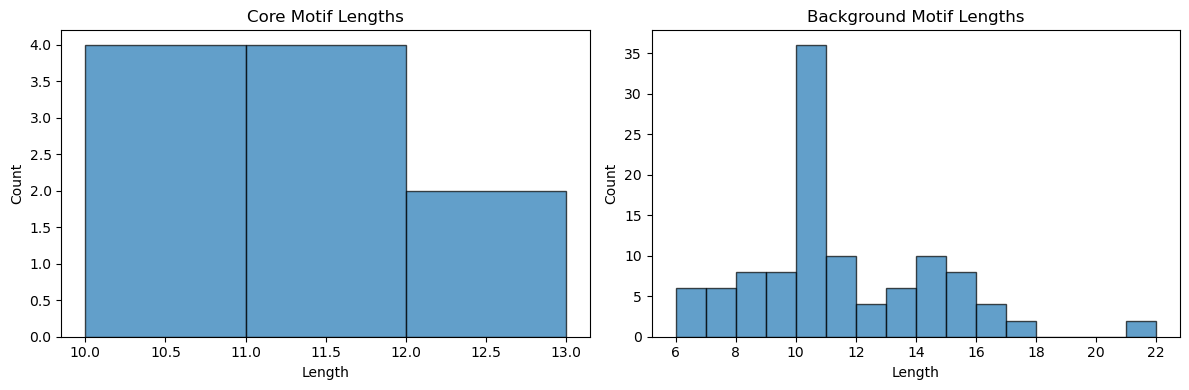

In [6]:
# 1. Analyze motif lengths
import matplotlib.pyplot as plt

def analyze_motif_lengths(motifs, motif_type=""):
    lengths = [m.shape[1] for m in motifs]
    print(f"\n{motif_type} Motif Length Statistics:")
    print(f"  Number of motifs: {len(motifs)}")
    print(f"  Min length: {min(lengths)}")
    print(f"  Max length: {max(lengths)}")
    print(f"  Mean length: {np.mean(lengths):.2f}")
    print(f"  Std length: {np.std(lengths):.2f}")
    return lengths

# Analyze core motifs (including reverse complements)
core_lengths = analyze_motif_lengths(core_motifs, "Core")

# Analyze background motifs  
background_lengths = analyze_motif_lengths(background_motifs, "Background")

# Plot distribution of motif lengths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(core_lengths, bins=range(min(core_lengths), max(core_lengths)+2), alpha=0.7, edgecolor='black')
ax1.set_title('Core Motif Lengths')
ax1.set_xlabel('Length')
ax1.set_ylabel('Count')

ax2.hist(background_lengths, bins=range(min(background_lengths), max(background_lengths)+2), alpha=0.7, edgecolor='black')
ax2.set_title('Background Motif Lengths')
ax2.set_xlabel('Length')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()



Core Motif Nucleotide Dominance Analysis:
  Average max probability per position: 0.777 ± 0.227
  Min max probability: 0.356
  Max max probability: 1.000
  Average entropy per position: 0.792 ± 0.702
  Fraction of positions with max_prob > 0.5: 0.796
  Fraction of positions with max_prob > 0.75: 0.611

Background Motif Nucleotide Dominance Analysis:
  Average max probability per position: 0.779 ± 0.224
  Min max probability: 0.265
  Max max probability: 1.000
  Average entropy per position: 0.782 ± 0.677
  Fraction of positions with max_prob > 0.5: 0.830
  Fraction of positions with max_prob > 0.75: 0.615


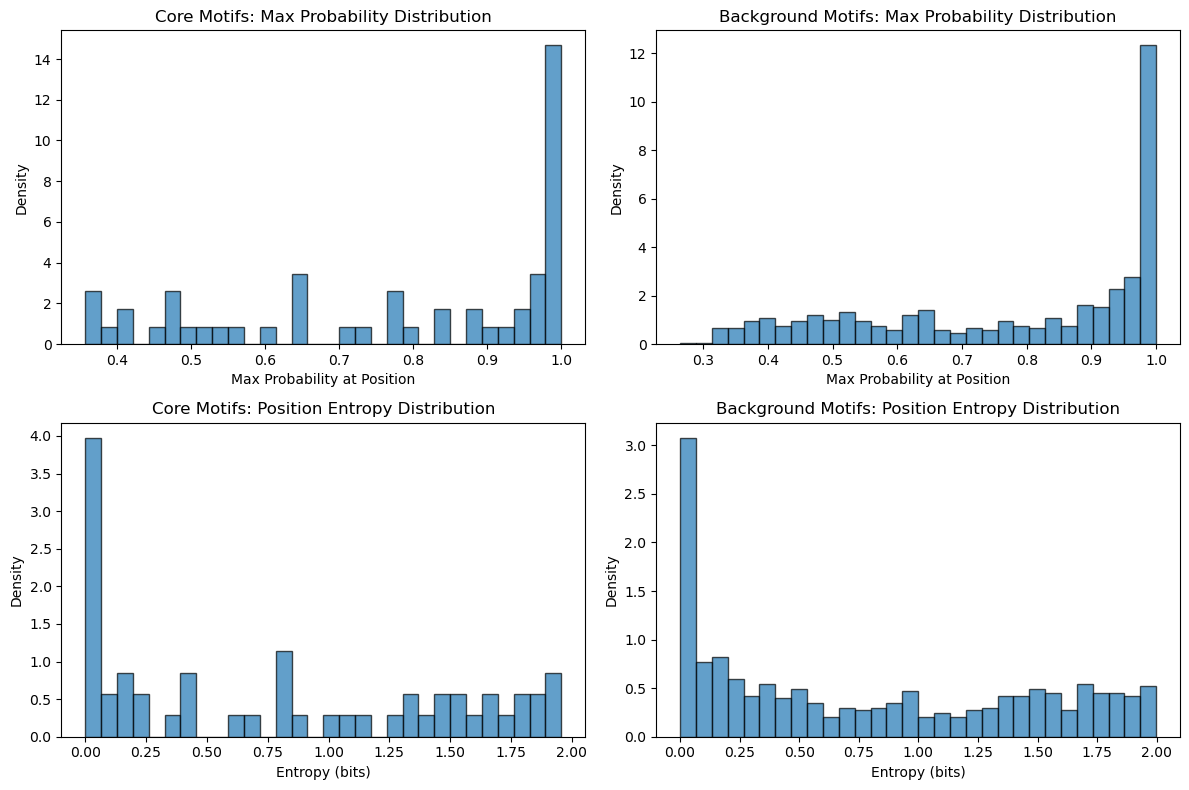

In [7]:
# 2. Analyze nucleotide dominance at each position
def analyze_nucleotide_dominance(motifs, motif_type=""):
    """Analyze how dominant each nucleotide is at each position"""
    
    print(f"\n{motif_type} Motif Nucleotide Dominance Analysis:")
    
    all_max_probs = []
    all_entropies = []
    
    for i, pwm in enumerate(motifs):
        # Max probability at each position
        max_probs = np.max(pwm, axis=0)
        all_max_probs.extend(max_probs)
        
        # Calculate entropy at each position (information content)
        # Entropy = -sum(p * log2(p)) where p is probability
        entropy_per_position = []
        for j in range(pwm.shape[1]):
            probs = pwm[:, j]
            # Add small epsilon to avoid log(0)
            probs_safe = probs + 1e-10
            entropy = -np.sum(probs_safe * np.log2(probs_safe))
            entropy_per_position.append(entropy)
        all_entropies.extend(entropy_per_position)
    
    print(f"  Average max probability per position: {np.mean(all_max_probs):.3f} ± {np.std(all_max_probs):.3f}")
    print(f"  Min max probability: {np.min(all_max_probs):.3f}")
    print(f"  Max max probability: {np.max(all_max_probs):.3f}")
    print(f"  Average entropy per position: {np.mean(all_entropies):.3f} ± {np.std(all_entropies):.3f}")
    print(f"  Fraction of positions with max_prob > 0.5: {np.mean(np.array(all_max_probs) > 0.5):.3f}")
    print(f"  Fraction of positions with max_prob > 0.75: {np.mean(np.array(all_max_probs) > 0.75):.3f}")
    
    return all_max_probs, all_entropies

# Analyze core and background motifs
core_max_probs, core_entropies = analyze_nucleotide_dominance(core_motifs, "Core")
bg_max_probs, bg_entropies = analyze_nucleotide_dominance(background_motifs, "Background")

# Visualize dominance distributions
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Max probability distributions
ax1.hist(core_max_probs, bins=30, alpha=0.7, edgecolor='black', density=True)
ax1.set_title('Core Motifs: Max Probability Distribution')
ax1.set_xlabel('Max Probability at Position')
ax1.set_ylabel('Density')

ax2.hist(bg_max_probs, bins=30, alpha=0.7, edgecolor='black', density=True)
ax2.set_title('Background Motifs: Max Probability Distribution')
ax2.set_xlabel('Max Probability at Position')
ax2.set_ylabel('Density')

# Entropy distributions
ax3.hist(core_entropies, bins=30, alpha=0.7, edgecolor='black', density=True)
ax3.set_title('Core Motifs: Position Entropy Distribution')
ax3.set_xlabel('Entropy (bits)')
ax3.set_ylabel('Density')

ax4.hist(bg_entropies, bins=30, alpha=0.7, edgecolor='black', density=True)
ax4.set_title('Background Motifs: Position Entropy Distribution')
ax4.set_xlabel('Entropy (bits)')
ax4.set_ylabel('Density')

plt.tight_layout()
plt.show()



Core Motif GC Content Analysis:
  Mean GC content: 0.601 ± 0.131
  Min GC content: 0.416
  Max GC content: 0.810
  Median GC content: 0.605

Background Motif GC Content Analysis:
  Mean GC content: 0.458 ± 0.156
  Min GC content: 0.196
  Max GC content: 0.810
  Median GC content: 0.426


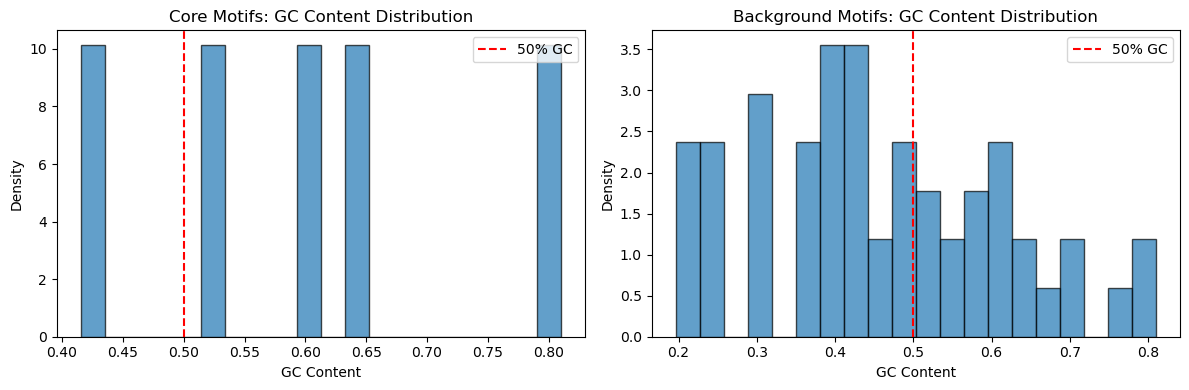


T-test comparing Core vs Background GC content: t-statistic=2.784, p-value=6.254e-03


In [8]:
# 3. Analyze GC content
def calculate_gc_content(pwm):
    """Calculate GC content from a PWM"""
    # Sum probabilities for G (index 2) and C (index 1)
    gc_prob = np.sum(pwm[1, :] + pwm[2, :]) / pwm.shape[1]
    return gc_prob

def analyze_gc_content(motifs, motif_type=""):
    """Analyze GC content across motifs"""
    gc_contents = [calculate_gc_content(m) for m in motifs]
    
    print(f"\n{motif_type} Motif GC Content Analysis:")
    print(f"  Mean GC content: {np.mean(gc_contents):.3f} ± {np.std(gc_contents):.3f}")
    print(f"  Min GC content: {np.min(gc_contents):.3f}")
    print(f"  Max GC content: {np.max(gc_contents):.3f}")
    print(f"  Median GC content: {np.median(gc_contents):.3f}")
    
    return gc_contents

# Analyze GC content
core_gc = analyze_gc_content(core_motifs, "Core")
bg_gc = analyze_gc_content(background_motifs, "Background")

# Visualize GC content
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(core_gc, bins=20, alpha=0.7, edgecolor='black', density=True)
ax1.axvline(0.5, color='red', linestyle='--', label='50% GC')
ax1.set_title('Core Motifs: GC Content Distribution')
ax1.set_xlabel('GC Content')
ax1.set_ylabel('Density')
ax1.legend()

ax2.hist(bg_gc, bins=20, alpha=0.7, edgecolor='black', density=True)
ax2.axvline(0.5, color='red', linestyle='--', label='50% GC')
ax2.set_title('Background Motifs: GC Content Distribution')
ax2.set_xlabel('GC Content')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Compare distributions
from scipy import stats
stat, pval = stats.ttest_ind(core_gc, bg_gc)
print(f"\nT-test comparing Core vs Background GC content: t-statistic={stat:.3f}, p-value={pval:.3e}")



Core Motif Random Match Analysis:
  Consensus sequence match probabilities:
    Mean log10 probability: -6.50
    Range: 10^-7.2 to 10^-6.0
  Partial match probabilities (conserved positions only):
    Mean probability: 1.343e-04
    Median probability: 6.104e-05
    Max probability: 2.441e-04

Background Motif Random Match Analysis:
  Consensus sequence match probabilities:
    Mean log10 probability: -6.62
    Range: 10^-12.6 to 10^-3.6
  Partial match probabilities (conserved positions only):
    Mean probability: 1.180e-03
    Median probability: 2.441e-04
    Max probability: 1.562e-02

Example motifs and their random match probabilities:

  Core Motif 1 (length 11):
    Consensus match: 2.38e-07
    Partial match: 2.44e-04
    Consensus: GCCCCGCCCCC
    Max probs: 0.49 0.71 0.77 1.00 0.99 0.53 1.00 1.00 0.76 0.73 0.57

  Core Motif 2 (length 11):
    Consensus match: 2.38e-07
    Partial match: 2.44e-04
    Consensus: GGGGGCGGGGC
    Max probs: 0.57 0.73 0.76 1.00 1.00 0.53 0.99

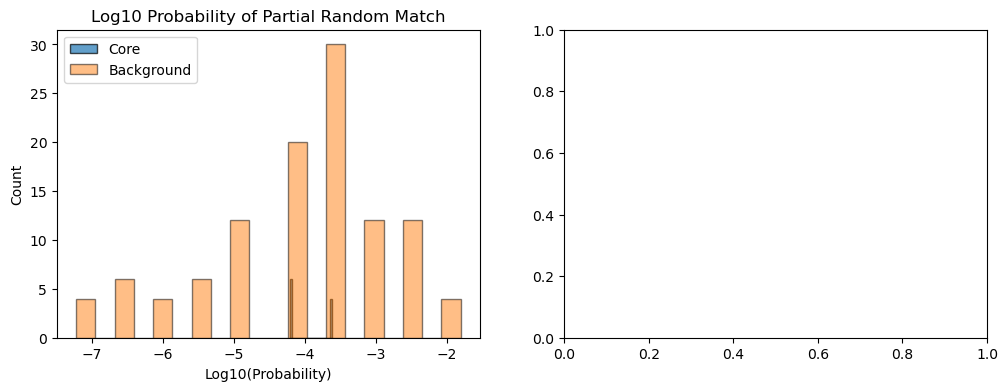

In [9]:
# 4. Analyze probability of random match with uniform PWM
def calculate_match_probability(pwm, threshold=0.75):
    """
    Calculate the probability that a uniform PWM could generate a sequence
    that matches the given motif above a certain similarity threshold.
    """
    # For each position, find the most likely nucleotide
    consensus = np.argmax(pwm, axis=0)
    
    # Probability of generating the consensus sequence from uniform PWM
    uniform_prob = 0.25
    consensus_prob_uniform = uniform_prob ** len(consensus)
    
    # Calculate a more realistic match probability considering partial matches
    # For each position, calculate probability of matching the top nucleotide
    position_match_probs = []
    for i in range(pwm.shape[1]):
        max_prob = np.max(pwm[:, i])
        # If this position has high information content (max_prob > threshold),
        # the chance of random match is 0.25
        if max_prob > threshold:
            position_match_probs.append(uniform_prob)
        else:
            # For less informative positions, any nucleotide is acceptable
            position_match_probs.append(1.0)
    
    # Overall match probability
    partial_match_prob = np.prod(position_match_probs)
    
    return consensus_prob_uniform, partial_match_prob, position_match_probs

def analyze_random_match_probability(motifs, motif_type=""):
    """Analyze probability of random matches for a set of motifs"""
    
    print(f"\n{motif_type} Motif Random Match Analysis:")
    
    consensus_probs = []
    partial_probs = []
    
    for pwm in motifs:
        cons_prob, part_prob, _ = calculate_match_probability(pwm)
        consensus_probs.append(cons_prob)
        partial_probs.append(part_prob)
    
    print(f"  Consensus sequence match probabilities:")
    print(f"    Mean log10 probability: {np.mean(np.log10(consensus_probs)):.2f}")
    print(f"    Range: 10^{np.min(np.log10(consensus_probs)):.1f} to 10^{np.max(np.log10(consensus_probs)):.1f}")
    
    print(f"  Partial match probabilities (conserved positions only):")
    print(f"    Mean probability: {np.mean(partial_probs):.3e}")
    print(f"    Median probability: {np.median(partial_probs):.3e}")
    print(f"    Max probability: {np.max(partial_probs):.3e}")
    
    return consensus_probs, partial_probs

# Analyze random match probabilities
core_cons, core_partial = analyze_random_match_probability(core_motifs, "Core")
bg_cons, bg_partial = analyze_random_match_probability(background_motifs, "Background")

# Visualize on log scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(np.log10(core_partial), bins=20, alpha=0.7, edgecolor='black', label='Core')
ax1.hist(np.log10(bg_partial), bins=20, alpha=0.5, edgecolor='black', label='Background')
ax1.set_title('Log10 Probability of Partial Random Match')
ax1.set_xlabel('Log10(Probability)')
ax1.set_ylabel('Count')
ax1.legend()

# Show a few example motifs with their match probabilities
print("\nExample motifs and their random match probabilities:")
for i in range(min(3, len(core_motifs))):
    pwm = core_motifs[i]
    cons_prob, part_prob, pos_probs = calculate_match_probability(pwm)
    print(f"\n  Core Motif {i+1} (length {pwm.shape[1]}):")
    print(f"    Consensus match: {cons_prob:.2e}")
    print(f"    Partial match: {part_prob:.2e}")
    
    # Show sequence logo-like representation
    consensus = ''.join(['ACGT'[np.argmax(pwm[:, j])] for j in range(pwm.shape[1])])
    max_probs = [np.max(pwm[:, j]) for j in range(pwm.shape[1])]
    print(f"    Consensus: {consensus}")
    print(f"    Max probs: {' '.join([f'{p:.2f}' for p in max_probs])}")

# Calculate expected frequency in the final dataset
print("\n" + "="*60)
print("EXPECTED RANDOM MATCH FREQUENCY IN FINAL DATASET")
print("="*60)

# Dataset parameters
num_sequences = 20000
seq_length = 200
min_motifs_per_seq = 3
max_motifs_per_seq = 5
avg_motifs_per_seq = (min_motifs_per_seq + max_motifs_per_seq) / 2

# Calculate average motif lengths
core_motif_lengths = [m.shape[1] for m in core_motifs]
avg_core_length = np.mean(core_motif_lengths)

# Total searchable positions
print(f"\nDataset Parameters:")
print(f"  Total sequences: {num_sequences:,}")
print(f"  Sequence length: {seq_length} nt")
print(f"  Motifs per sequence: {min_motifs_per_seq}-{max_motifs_per_seq} (avg: {avg_motifs_per_seq})")
print(f"  Average core motif length: {avg_core_length:.1f} nt")

# Calculate expected random matches per motif type
print(f"\nExpected Random Matches (Core Motifs):")

# For each core motif, calculate expected matches
expected_matches_per_motif = []
for i, pwm in enumerate(core_motifs):
    motif_length = pwm.shape[1]
    _, part_prob, _ = calculate_match_probability(pwm)
    
    # Number of possible start positions per sequence
    positions_per_seq = seq_length - motif_length + 1
    
    # Total positions across all sequences
    total_positions = positions_per_seq * num_sequences
    
    # Expected matches
    expected_matches = total_positions * part_prob
    expected_matches_per_motif.append(expected_matches)
    
    if i < 3:  # Show first 3 motifs
        print(f"  Motif {i+1}: {expected_matches:.2f} matches ({expected_matches/num_sequences:.4f} per sequence)")

# Overall statistics
print(f"\n  Average expected matches per motif: {np.mean(expected_matches_per_motif):.2f}")
print(f"  Total expected matches (all core motifs): {np.sum(expected_matches_per_motif):.2f}")
print(f"  Expected matches per sequence: {np.sum(expected_matches_per_motif)/num_sequences:.4f}")

# Compare to actual motifs inserted
total_actual_motifs = num_sequences * avg_motifs_per_seq
print(f"\nComparison to Actual Inserted Motifs:")
print(f"  Actual motifs inserted: {total_actual_motifs:,.0f}")
print(f"  Expected random matches: {np.sum(expected_matches_per_motif):.0f}")
print(f"  Signal-to-noise ratio: {total_actual_motifs/np.sum(expected_matches_per_motif):.1f}:1")

# Calculate for background sequences (which use uniform PWM)
print(f"\nFor Background Sequences (50% of dataset):")
num_bg_sequences = num_sequences // 2
print(f"  Expected false positives in background: {np.sum(expected_matches_per_motif)/2:.1f}")
print(f"  False positive rate: {(np.sum(expected_matches_per_motif)/2)/num_bg_sequences:.4f} per background sequence")



=== COMPREHENSIVE COMPARISON: Core vs Background Motifs ===

1. LENGTH COMPARISON:
   Core: mean=10.8, std=0.7
   Background: mean=11.0, std=3.0
   T-test: t=-0.207, p=8.364e-01

2. INFORMATION CONTENT COMPARISON:
   Core: mean=13.05 bits, std=0.96
   Background: mean=13.40 bits, std=3.92
   T-test: t=-0.284, p=7.770e-01

3. AVERAGE MAX PROBABILITY COMPARISON:
   Core: mean=0.776, std=0.016
   Background: mean=0.783, std=0.067
   T-test: t=-0.322, p=7.484e-01

4. SPECIFICITY SCORE COMPARISON (fraction positions > 0.75):
   Core: mean=0.613, std=0.052
   Background: mean=0.622, std=0.138
   T-test: t=-0.204, p=8.388e-01


/vol/tmp/users/yhan/ipykernel_1284077/3331779308.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([comparison_results['core_ic'], comparison_results['bg_ic']],
/vol/tmp/users/yhan/ipykernel_1284077/3331779308.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([comparison_results['core_spec'], comparison_results['bg_spec']],
/vol/tmp/users/yhan/ipykernel_1284077/3331779308.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot([comparison_results['core_avg_max'], comparison_results['bg_avg_max']],
/vol/tmp/users/yhan/ipykernel_1284077/3331779308.py:93: MatplotlibDeprecationWarnin

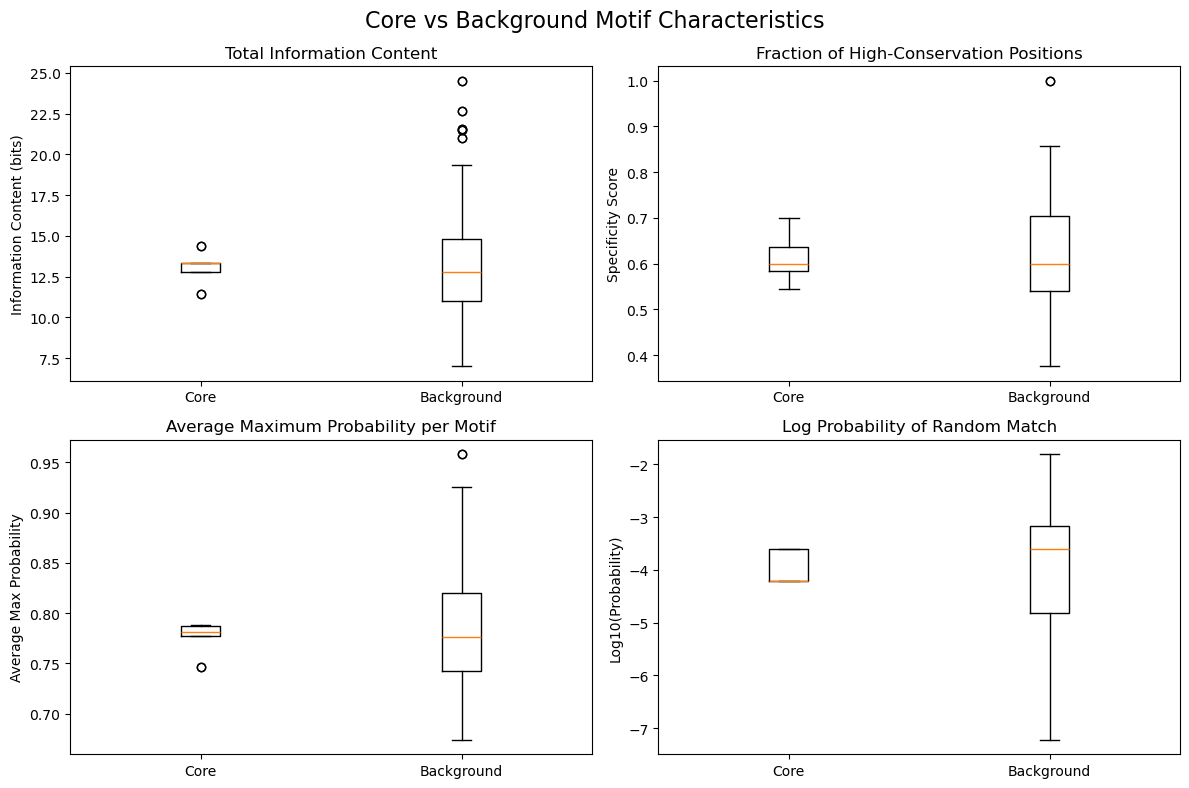

In [9]:
# 5. Comprehensive comparison between core and background motifs
def calculate_information_content(pwm):
    """Calculate total information content of a PWM"""
    ic = 0
    for i in range(pwm.shape[1]):
        probs = pwm[:, i]
        # Add small epsilon to avoid log(0)
        probs_safe = probs + 1e-10
        entropy = -np.sum(probs_safe * np.log2(probs_safe))
        # Max entropy is 2 bits for 4 nucleotides
        ic += (2 - entropy)
    return ic

def compare_motif_sets(core_motifs, background_motifs):
    """Comprehensive comparison of core vs background motifs"""
    
    print("\n=== COMPREHENSIVE COMPARISON: Core vs Background Motifs ===\n")
    
    # 1. Length comparison
    core_lengths = [m.shape[1] for m in core_motifs]
    bg_lengths = [m.shape[1] for m in background_motifs]
    
    print("1. LENGTH COMPARISON:")
    print(f"   Core: mean={np.mean(core_lengths):.1f}, std={np.std(core_lengths):.1f}")
    print(f"   Background: mean={np.mean(bg_lengths):.1f}, std={np.std(bg_lengths):.1f}")
    stat, pval = stats.ttest_ind(core_lengths, bg_lengths)
    print(f"   T-test: t={stat:.3f}, p={pval:.3e}")
    
    # 2. Information content comparison
    core_ic = [calculate_information_content(m) for m in core_motifs]
    bg_ic = [calculate_information_content(m) for m in background_motifs]
    
    print("\n2. INFORMATION CONTENT COMPARISON:")
    print(f"   Core: mean={np.mean(core_ic):.2f} bits, std={np.std(core_ic):.2f}")
    print(f"   Background: mean={np.mean(bg_ic):.2f} bits, std={np.std(bg_ic):.2f}")
    stat, pval = stats.ttest_ind(core_ic, bg_ic)
    print(f"   T-test: t={stat:.3f}, p={pval:.3e}")
    
    # 3. Average max probability comparison
    core_avg_max = [np.mean(np.max(m, axis=0)) for m in core_motifs]
    bg_avg_max = [np.mean(np.max(m, axis=0)) for m in background_motifs]
    
    print("\n3. AVERAGE MAX PROBABILITY COMPARISON:")
    print(f"   Core: mean={np.mean(core_avg_max):.3f}, std={np.std(core_avg_max):.3f}")
    print(f"   Background: mean={np.mean(bg_avg_max):.3f}, std={np.std(bg_avg_max):.3f}")
    stat, pval = stats.ttest_ind(core_avg_max, bg_avg_max)
    print(f"   T-test: t={stat:.3f}, p={pval:.3e}")
    
    # 4. Specificity score (fraction of highly conserved positions)
    def specificity_score(pwm, threshold=0.75):
        return np.mean(np.max(pwm, axis=0) > threshold)
    
    core_spec = [specificity_score(m) for m in core_motifs]
    bg_spec = [specificity_score(m) for m in background_motifs]
    
    print("\n4. SPECIFICITY SCORE COMPARISON (fraction positions > 0.75):")
    print(f"   Core: mean={np.mean(core_spec):.3f}, std={np.std(core_spec):.3f}")
    print(f"   Background: mean={np.mean(bg_spec):.3f}, std={np.std(bg_spec):.3f}")
    stat, pval = stats.ttest_ind(core_spec, bg_spec)
    print(f"   T-test: t={stat:.3f}, p={pval:.3e}")
    
    return {
        'core_ic': core_ic, 'bg_ic': bg_ic,
        'core_spec': core_spec, 'bg_spec': bg_spec,
        'core_avg_max': core_avg_max, 'bg_avg_max': bg_avg_max
    }

# Run comprehensive comparison
comparison_results = compare_motif_sets(core_motifs, background_motifs)

# Create summary visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Information content
ax1.boxplot([comparison_results['core_ic'], comparison_results['bg_ic']], 
            labels=['Core', 'Background'])
ax1.set_ylabel('Information Content (bits)')
ax1.set_title('Total Information Content')

# Specificity scores
ax2.boxplot([comparison_results['core_spec'], comparison_results['bg_spec']], 
            labels=['Core', 'Background'])
ax2.set_ylabel('Specificity Score')
ax2.set_title('Fraction of High-Conservation Positions')

# Average max probability
ax3.boxplot([comparison_results['core_avg_max'], comparison_results['bg_avg_max']], 
            labels=['Core', 'Background'])
ax3.set_ylabel('Average Max Probability')
ax3.set_title('Average Maximum Probability per Motif')

# Random match probabilities
ax4.boxplot([np.log10(core_partial), np.log10(bg_partial)], 
            labels=['Core', 'Background'])
ax4.set_ylabel('Log10(Probability)')
ax4.set_title('Log Probability of Random Match')

plt.suptitle('Core vs Background Motif Characteristics', fontsize=16)
plt.tight_layout()
plt.show()


Example Core Motifs (forward strand only):


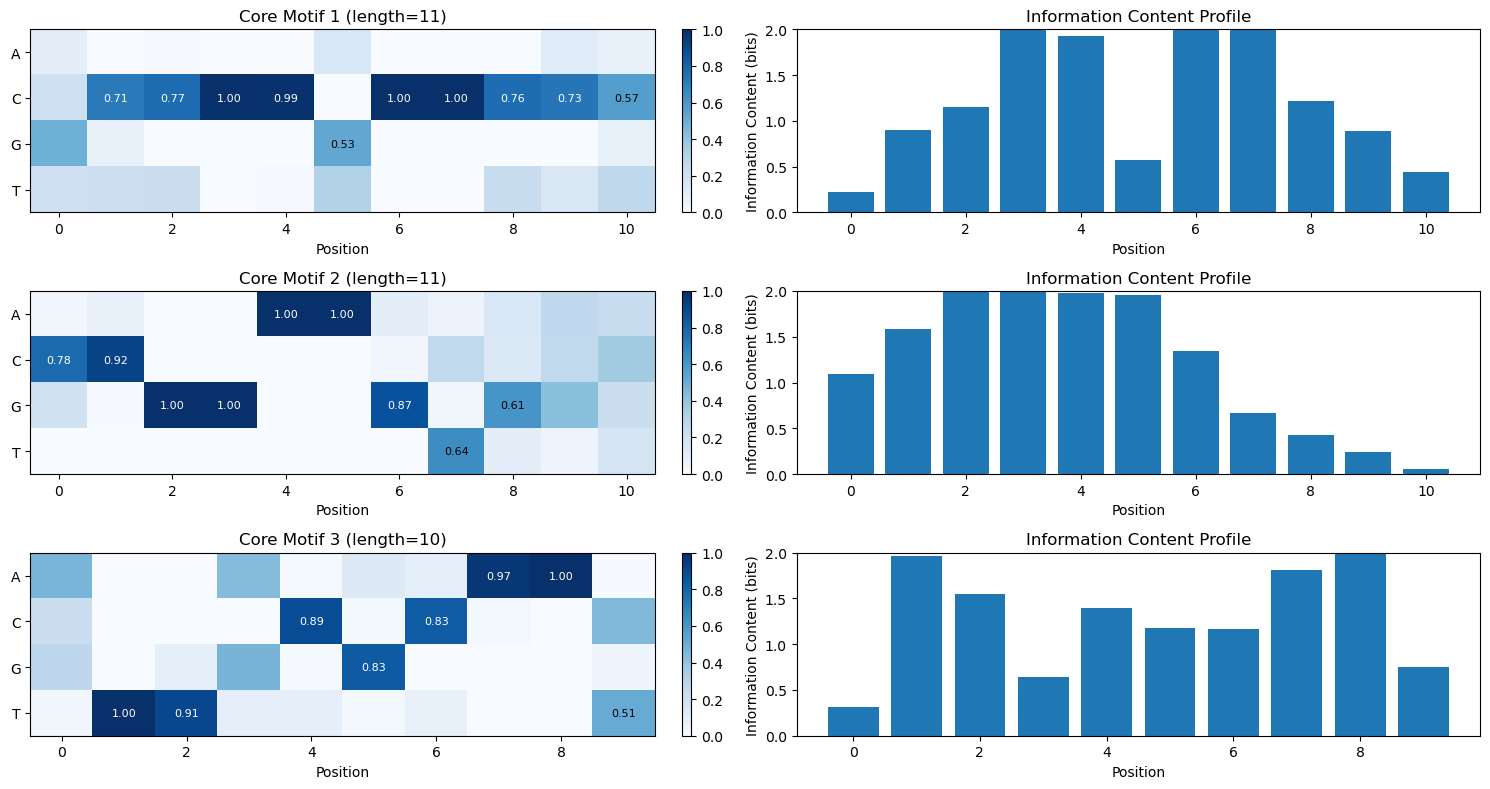


Example Background Motifs:


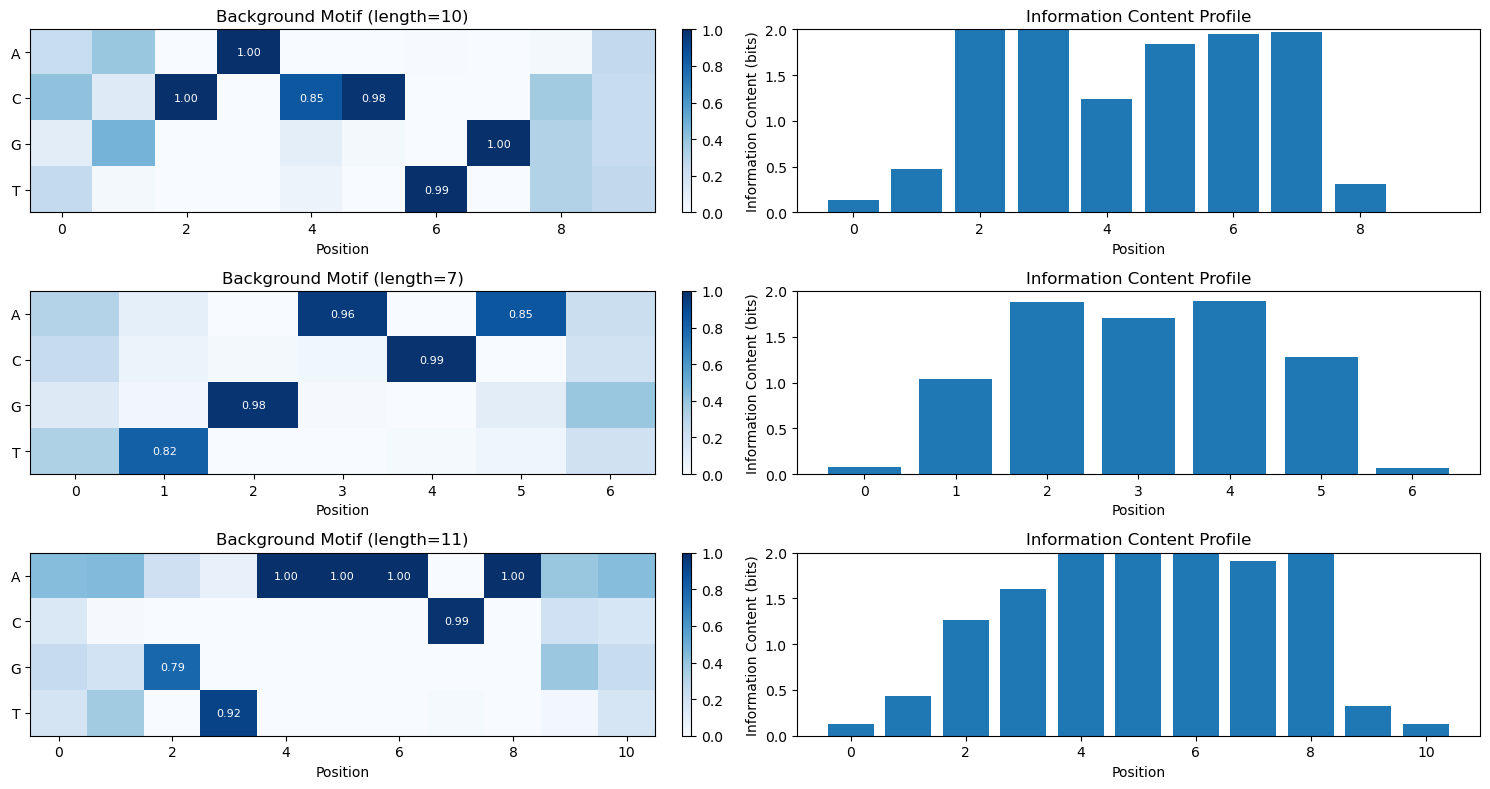


=== SUMMARY ===
Total core motifs: 10 (including reverse complements)
Total background motifs: 110
Core motifs show lower information content on average
Core motifs are less specific than background motifs


In [10]:
# 6. Visualize example motifs as sequence logos
def plot_motif_logo(pwm, title="", ax=None):
    """Simple visualization of a PWM as a heatmap (simplified sequence logo)"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 2))
    
    # Create heatmap
    im = ax.imshow(pwm, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    
    # Set labels
    ax.set_yticks(range(4))
    ax.set_yticklabels(['A', 'C', 'G', 'T'])
    ax.set_xlabel('Position')
    ax.set_title(title)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Add text annotations for high probability positions
    for i in range(pwm.shape[1]):
        max_idx = np.argmax(pwm[:, i])
        max_val = pwm[max_idx, i]
        if max_val > 0.5:
            ax.text(i, max_idx, f'{max_val:.2f}', 
                   ha='center', va='center', color='white' if max_val > 0.7 else 'black',
                   fontsize=8)
    
    return ax

# Visualize examples from core and background motifs
print("Example Core Motifs (forward strand only):")
fig, axes = plt.subplots(3, 2, figsize=(15, 8))

# Show first 3 core motifs (forward strand only, so step by 2)
for i in range(3):
    if i*2 < len(core_motifs):
        idx = i*2  # Get only forward strand motifs
        pwm = core_motifs[idx]
        
        # Left column: PWM heatmap
        plot_motif_logo(pwm, f"Core Motif {i+1} (length={pwm.shape[1]})", axes[i, 0])
        
        # Right column: Information content per position
        ax = axes[i, 1]
        ic_per_pos = []
        for j in range(pwm.shape[1]):
            probs = pwm[:, j] + 1e-10
            entropy = -np.sum(probs * np.log2(probs))
            ic_per_pos.append(2 - entropy)
        
        ax.bar(range(len(ic_per_pos)), ic_per_pos)
        ax.set_xlabel('Position')
        ax.set_ylabel('Information Content (bits)')
        ax.set_title(f'Information Content Profile')
        ax.set_ylim(0, 2)

plt.tight_layout()
plt.show()

# Show example background motifs
print("\nExample Background Motifs:")
fig, axes = plt.subplots(3, 2, figsize=(15, 8))

# Show 3 random background motifs
bg_indices = np.random.choice(len(background_motifs)//2, 3, replace=False) * 2

for i, idx in enumerate(bg_indices):
    pwm = background_motifs[idx]
    
    # Left column: PWM heatmap
    plot_motif_logo(pwm, f"Background Motif (length={pwm.shape[1]})", axes[i, 0])
    
    # Right column: Information content per position
    ax = axes[i, 1]
    ic_per_pos = []
    for j in range(pwm.shape[1]):
        probs = pwm[:, j] + 1e-10
        entropy = -np.sum(probs * np.log2(probs))
        ic_per_pos.append(2 - entropy)
    
    ax.bar(range(len(ic_per_pos)), ic_per_pos)
    ax.set_xlabel('Position')
    ax.set_ylabel('Information Content (bits)')
    ax.set_title(f'Information Content Profile')
    ax.set_ylim(0, 2)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== SUMMARY ===")
print(f"Total core motifs: {len(core_motifs)} (including reverse complements)")
print(f"Total background motifs: {len(background_motifs)}")
print(f"Core motifs show {'higher' if np.mean(comparison_results['core_ic']) > np.mean(comparison_results['bg_ic']) else 'lower'} information content on average")
print(f"Core motifs are {'more' if np.mean(comparison_results['core_spec']) > np.mean(comparison_results['bg_spec']) else 'less'} specific than background motifs")


# Simulation overview


We define a regulatory grammar, $G$, as a the interactions of specific motifs spaced in specific spatial positions. Each grammar consists of a position weight matrix (PWM) with implanted motifs from which a synthetic sequence is generated from.  In this synthetic dataset, each simulated sequence is generated from a given grammar that is randomly translated, but the motifs and spatial positions between motifs within the grammar are conserved. 

To generate each regulatory grammar, we first create a model which consists of a subset of motifs and their spatial distances with respect to one another. We limit the pool of possible motifs to $M$ motifs to include all of the core motifs and a subset of motifs (num_motif total motifs) which are randomly sampled from the pool of JASPAR database (under the list tf_motifs).  For a given grammar, the number of motifs is determined by sampling an exponential distribution (parameterized by interaction_rate).  Then, the minimum is taken between this value and the max_motif, which imposes the constraint of a maximum number of motifs for a given grammar.  

The motifs are randomly sampled from the pool of available motifs and the distance between each motif is determined by randomly sampling an exponential distribution (parameterized by distance_scale) plus a minimum distance between motifs (distance_offset). The motifs are placed along a PWM in locations determined by the distances between motifs. For simplicity, we will use a uniform distribution for the PWMs for all 'non-motif' nucleotides, i.e. $p = 1/4$.
This constitutes the regulatory grammar model, from which synthetic sequences can be simulated from.  Moreover, each regulatory grammar is associated to a given class.


Note that here we elect not to include alternative regulatory codes for a given class directly.  Since we are sampling from a smaller pool, we assume alternative codes will give rise to a different phenotype, specified by a different class.   Also, we do not alter the spacing between the motifs or include noisy motifs in the grammar model.  All of the noise comes from random sampling in generating the sequence and the translation of the grammar.  



In [ ]:
def generate_model(core_motifs, min_interactions, max_interactions, seq_length):
    
    num_motif = len(core_motifs)
    cum_dist = np.cumsum([0, 0, 0.5, 0.25, 0.17, .05, 0.3])
    
    # sample core motifs for each grammar
    valid_sim = False
    while not valid_sim:

        # determine number of core motifs in a given grammar model
        num_interactions = np.where(np.random.rand() > cum_dist)[0][-1]+2 #np.random.randint(min_interactions, max_interactions)

        # randomly sample motifs
        sim_motifs = np.random.randint(num_motif, size=num_interactions)
        num_sim_motifs = len(sim_motifs)
        #sim_motifs = sim_motifs[np.random.permutation(num_sim_motifs)]
        
        # verify that distances aresmaller than sequence length
        distance = 0
        for i in range(num_sim_motifs):
            distance += core_motifs[sim_motifs[i]].shape[1]
        if seq_length > distance > 0:
            valid_sim = True    

    # simulate distances between motifs + start 
    valid_dist = False
    while not valid_dist:
        remainder = seq_length - distance
        sep = np.random.uniform(0, 2, size=num_sim_motifs+1)
        sep = np.round(sep/sum(sep)*remainder).astype(int)
        if np.sum(sep) == remainder:
            valid_dist = True

    # build a PWM for each regulatory grammar
    pwm = np.ones((4,sep[0]))/4
    for i in range(num_sim_motifs):
        pwm = np.hstack([pwm, core_motifs[sim_motifs[i]], np.ones((4,sep[i+1]))/4])

    return pwm


def simulate_sequence(sequence_pwm):
    """simulate a sequence given a sequence model"""

    nucleotide = 'ACGT'

    # sequence length
    seq_length = sequence_pwm.shape[1]

    # generate uniform random number for each nucleotide in sequence
    Z = np.random.uniform(0,1,seq_length)

    # calculate cumulative sum of the probabilities
    cum_prob = sequence_pwm.cumsum(axis=0)

    # go through sequence and find bin where random number falls in cumulative 
    # probabilities for each nucleotide
    one_hot_seq = np.zeros((4, seq_length))
    for i in range(seq_length):
        index=[j for j in range(4) if Z[i] < cum_prob[j,i]][0]
        one_hot_seq[index,i] = 1
    return one_hot_seq


# Simulation overview

The number of sequences for each grammar is determined by a randomly sampled population fraction (pop_fraction).  For a each grammar model, the total number of sequences simulated is then, $N$ times its population fraction. For each sequence, the grammar model is randomly translated according to a Gaussian distribution, but with constraints to make sure the entire grammar is contained within the sequence.  Then, the cumulative sum at each nucleotide position of the translated model is calculated.  A uniform random number from 0 to 1 is generated and the bin with which it falls with respect to the the cumulative proprabilities specifies the simulated nucleotide value.  THis is done for each nucleotide position to simulate the entire sequence of length $S$. 

After all of the the synthetic sequences are generated, i.e. the sequence model (translated grammar), and an indicator vector of length $G$ specifying which grammar generated the sequence, the dataset is split into training, cross-validation, and a test set.  Then each dataset is stored in a hdf5 file.  


In [ ]:
# dataset parameters
num_seq = 20000             # number of sequences
seq_length = 200            # length of sequence
min_interactions = 3        # exponential rate of number of motifs for each grammar
max_interactions = 5
# generate sythetic sequences as a one-hot representation
seq_pwm = []
seq_model = []    
num_sim = int(num_seq/2)
for j in range(num_sim):
    signal_pwm = generate_model(core_motifs, min_interactions, max_interactions, seq_length)
    seq_pwm.append(simulate_sequence(signal_pwm))
    seq_model.append(signal_pwm)

# simulate a background sequence
for j in range(num_sim):
    background_pwm = generate_model(background_motifs, 2, max_interactions, seq_length)
    seq_pwm.append(simulate_sequence(background_pwm))
    seq_model.append(background_pwm)
    
# generate labels
seq_label = np.vstack([np.ones((num_sim,1)), np.zeros((num_sim, 1))])


In [ ]:
def split_data(data, label, model, split_size):
    """split data into train set, cross-validation set, and test set"""
    
    def subset_data(data, label, model, sub_index):
        """returns a subset of the data and labels based on sub_index"""
        
        num_sub = len(sub_index)
        sub_set_label = []
        sub_set_seq = []
        sub_set_model = []
        for index in sub_index:
            sub_set_seq.append([data[index]])
            sub_set_label.append(label[index])
            sub_set_model.append([model[index]])
        sub_set_seq = np.vstack(sub_set_seq)
        sub_set_label = np.vstack(sub_set_label)
        sub_set_model = np.vstack(sub_set_model)
    
        return (sub_set_seq, sub_set_label, sub_set_model)

    
    # determine indices of each dataset
    N = len(data)
    cum_index = np.cumsum(np.multiply([0, split_size[0], split_size[1], split_size[2]],N)).astype(int) 

    # shuffle data
    shuffle = np.random.permutation(N)

    # training dataset
    train_index = shuffle[range(cum_index[0], cum_index[1])]
    cross_validation_index = shuffle[range(cum_index[1], cum_index[2])]
    test_index = shuffle[range(cum_index[2], cum_index[3])]

    # create subsets of data based on indices 
    print('Generating training data')
    train = subset_data(data, label, model, train_index)

    print('Generating cross-validation data')
    cross_validation = subset_data(data, label, model, cross_validation_index)
    
    print('Generating test data')    
    test = subset_data(data, label, model, test_index)
    
    return train, cross_validation, test


def save_dataset(savepath, train, valid, test):
    f = h5py.File(savepath, "w")
    dset = f.create_dataset("X_train", data=train[0], compression="gzip")
    dset = f.create_dataset("Y_train", data=train[1], compression="gzip")
    dset = f.create_dataset("model_train", data=train[2], compression="gzip")
    dset = f.create_dataset("X_valid", data=valid[0], compression="gzip")
    dset = f.create_dataset("Y_valid", data=valid[1], compression="gzip")
    dset = f.create_dataset("model_valid", data=valid[2], compression="gzip")
    dset = f.create_dataset("X_test", data=test[0], compression="gzip")
    dset = f.create_dataset("Y_test", data=test[1], compression="gzip")
    dset = f.create_dataset("model_test", data=test[2], compression="gzip")
    f.close()
    
    
# split into training, cross-validation, and test sets
print("Splitting dataset into train, cross-validation, and test")
train_size = 0.7
cross_validation_size = 0.1
test_size = 0.2
split_size = [train_size, cross_validation_size, test_size]
train, valid, test = split_data(seq_pwm, seq_label, seq_model, split_size)

# save to file
filename =  'synthetic_code_dataset.h5' 
file_path = os.path.join(savepath, filename)
print('Saving to: ' + file_path)
save_dataset(file_path, train, valid, test)